In [15]:
import sisl 
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from ase.visualize import view
from mytools.plots import thesis_fig

from matplotlib.ticker import AutoMinorLocator

In [16]:
def showidx(geom):
    x,y,z = geom.xyz.T
    
    fig,ax = plt.subplots()
    ax.scatter(x, y, c='k')
    for atom in range(geom.na):
        ax.annotate(text=atom, xy=(x[atom], y[atom]))
    return fig, ax


In [17]:
labels = ['zigzag', 'armchair']

In [18]:
lab = labels[0]
Nw = 20

outdir = Path(f'./TBT_{lab}')
outdir = Path(f'./TBT-Nw{Nw}-{lab}')
outdir.exists()

True

In [19]:
# SEfile = outdir / f'{lab}.TBT.SE.nc'
SEfile = outdir / f'{lab}.TBT.SE.nc'
tbtse = sisl.io.get_sile(SEfile)
En = tbtse.E
kpts = tbtse.k
wk = tbtse.wk
eta = tbtse.eta()
a_dev = tbtse.a_dev

def GetSigma(e, elec=0, k=[0.,0.,0.,]):
    tmp = tbtse.self_energy(elec=elec,E=e,k=k,sort=True).data
    pvt = tbtse.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)  # and downfolded to smaller region
    no_d = tbtse.no_d ## down-folded region size
    #print(tmp[0].dtype)
    ZeroMat = 0*np.eye(no_d, dtype=np.complex128)
    Sigma = ZeroMat.copy()  # transform to original orbit
    Sigma[pvt, pvt.T] += tmp  # transform to original orbital-index using pvt arrays.
    return Sigma


E = 0.1
E += 0.005
left_se = GetSigma(E, elec=0)
right_se = GetSigma(E, elec=1)

slice(24, 56, 1) slice(104, 136, 1) slice(184, 216, 1)


(np.float64(23.927),
 np.float64(59.853),
 np.float64(-0.3074390183434757),
 np.float64(6.456219385212989))

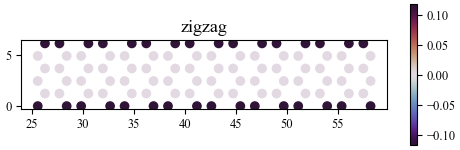

In [20]:
num_atoms = 4 * 4
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
print(idxL, idxD, idxR)
xyz = tbtse.xyz

E = 0.
E += 0.005
kpts = [0., 0., 0.]
site0 = NL//2
site1 = ND-NR//2
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))

vmax = np.max(np.abs([coup0, coup1]))
vmin = -vmax
cmap='twilight_shifted'
fig, ax = plt.subplots()
ax.set_title(lab)
ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=np.diag(coup0)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)
sc=ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=np.diag(coup1)[idxL], vmin=vmin, vmax=vmax, cmap=cmap)

fig.colorbar(sc)
ax.axis('scaled')

slice(24, 56, 1) slice(104, 136, 1) slice(184, 216, 1)
240


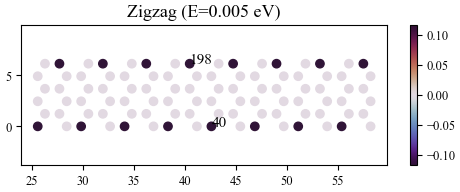

In [21]:
num_atoms = 4 * 4
ND = tbtse.na
NL = tbtse.na_down(0)
NR = tbtse.na_down(1)
idxL = slice(NL//2-num_atoms, NL//2+num_atoms, 1)
idxD = slice(ND//2-num_atoms, ND//2+num_atoms, 1)
idxR = slice(ND-NR//2-num_atoms, ND-NR//2+num_atoms, 1)
xyz = tbtse.xyz
print(idxL, idxD, idxR)
print(ND)

if lab == 'zigzag':
    site1_offset = -2
elif lab == 'armchair':
    site1_offset = 3

E = 0.
E += 0.005
kpts = [0., 0.0, 0.]
site0 = NL//2 - 0
site1 = ND-NR//2 + site1_offset
# site1 = ND-NR//2 +3
coup0 = np.imag(GetSigma(e=E, elec=0, k=kpts))
coup1 = np.imag(GetSigma(e=E, elec=1, k=kpts))

Broadening = np.zeros(shape=(ND, ND), dtype=np.complex128)
Broadening[idxL, idxL] += GetSigma(e=E, elec=0, k=kpts)[idxL, idxL]
Broadening[idxR, idxR] += GetSigma(e=E, elec=1, k=kpts)[idxL, idxL]

# vmax = np.max(np.abs([coup0, coup1]))
# vmin = -vmax
vmax = np.max(np.abs([coup0[idxL, site0], coup1[idxL, site0 + site1_offset]]))
vmin = -vmax
cmap='twilight_shifted'
fig, ax = plt.subplots()
ax.set_title(lab.capitalize() + f' (E={E:.3f} eV)')
sc = ax.scatter(x=xyz[idxL, 0], y=xyz[idxL, 1], label='left', c=coup0[idxL, site0], vmin=vmin, vmax=vmax, cmap=cmap)
ax.scatter(x=xyz[idxD, 0], y=xyz[idxD, 1], label='device', c=np.zeros(shape=(2*num_atoms)), vmin=vmin, vmax=vmax, cmap=cmap)
sc = ax.scatter(x=xyz[idxR, 0], y=xyz[idxR, 1], label='Right', c=coup1[idxL, site0 + site1_offset], vmin=vmin, vmax=vmax, cmap=cmap)
# ax.scatter(x=xyz[:ND//2, 0], y=xyz[:ND//2, 1], c=np.imag(Broadening[:ND//2, site0]), vmin=vmin, vmax=vmax, cmap=cmap)
# sc = ax.scatter(x=xyz[ND//2:, 0], y=xyz[ND//2:, 1], c=np.imag(Broadening[ND//2:, site1]), vmin=vmin, vmax=vmax, cmap=cmap)
fig.colorbar(sc)
for atom in [site0, site1]:
    ax.annotate(text=atom, xy=(xyz[atom, :2]))

fig.axes[0].set_aspect('equal', adjustable='datalim')
# ax.axis('square')

# Plotting conv for Siesta calcs

In [22]:
cwd = Path("./")
arm_dir = list(cwd.parent.glob("TBT-Nw*-armchair"))
zig_dir = list(cwd.parent.glob("TBT-Nw*-zigzag"))



def GetSE(file, E=0,
        elec=0,
        k=[0.0, 0.0, 0.0]):
    tmp = file.self_energy(elec=0, E=E, k=k, sort=True).data
    pvt = file.pivot(elec=elec, in_device=True, sort=True).reshape(-1, 1)
    no_d = file.na_d
    Sigma = np.zeros((no_d, no_d), dtype=np.complex128)
    Sigma[pvt, pvt.T] += tmp
    return Sigma


E = 0.
E += 0.005
kpts = [0., 0., 0.]


nZ = []
nA = []
ZonL = []
ZonR = []
AonL = []
AonR = []
for zig in zig_dir:
    n = int(str(zig).split('-')[1][2:])
    nZ.append(n)
    siteoffset = -2
    seZ = sisl.io.get_sile(zig / 'zigzag.TBT.SE.nc')
    nd = seZ.na
    nl = seZ.na_down(0)
    nr = seZ.na_down(1)
    # print(f"zigzag: n={n}, na={4*n*3}, nd={nd}, nl={nl}, nr={nr}")
    SEL = np.imag(GetSE(seZ, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seZ, E=E, elec=1, k=kpts))
    ZonL.append(SEL[nl//2, nl//2])
    ZonR.append(SER[nr//2+siteoffset, nr//2+siteoffset])

for arm in arm_dir:
    siteoffset = 3
    
    n = int(str(arm).split('-')[1][2:])
    nA.append(n)
    seA= sisl.io.get_sile(arm / 'armchair.TBT.SE.nc')
    nd = seA.na
    nl = seA.na_down(0)
    nr = seA.na_down(1)
    # print(f"armchair: n={n}, na={4*n*3}, nd={nd}, nl={nl}, nr={nr}")
    SEL = np.imag(GetSE(seA, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seA, E=E, elec=1, k=kpts))
    AonL.append(SEL[nl//2, nl//2])
    AonR.append(SER[nr//2+siteoffset, nr//2+siteoffset])


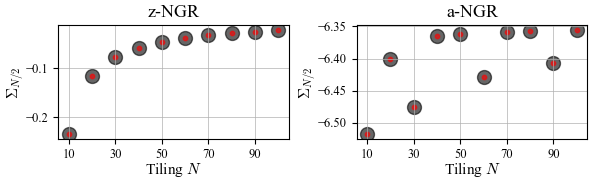

In [34]:
fig, ax = thesis_fig(fraction=1, subplots=(1,2))
ax[0].set_title('z-NGR')
# ax[0].semilogy(nZ, np.abs(ZonL), c='k', linestyle="", marker='o', alpha=0.9, markersize=8)
# ax[0].semilogy(nZ, np.abs(ZonR), c='r', linestyle="", marker='o', alpha=0.9, markersize=2)
ax[0].scatter(nZ, ZonL, c='k', alpha=0.6, s=100)
ax[0].scatter(nZ, ZonR, c='r', alpha=0.6, s=10)
ax[0].set(xticks=np.sort(nZ)[::2],
          xlabel='Tiling $N$',
          ylabel=r'$\Sigma_{N/2}$')
ax[0].grid()

ax[1].set_title('a-NGR')
# ax[1].semilogy(nA, np.abs(AonL), c='k', linestyle="", marker='o', alpha=0.9, markersize=8)
# ax[1].semilogy(nA, np.abs(AonR), c='r', linestyle="", marker='o', alpha=0.9, markersize=2)
ax[1].scatter(nA, AonL, c='k', alpha=0.6, s=100)
ax[1].scatter(nA, AonR, c='r', alpha=0.6, s=10)
ax[1].set(xticks=np.sort(nA)[::2],
          xlabel='Tiling $N$',
          ylabel=r'$\Sigma_{N/2}$')
ax[1].grid(True)

fig.set_constrained_layout(True)
fig.savefig('./figures/onsite_v_tiling_tbtrans')

# Coupling

In [35]:
E = 0.005
kpts = [0., 0., 0.]

nZ = []
nA = []
ZcoupL = []
ZcoupR = []
AcoupL = []
AcoupR = []
for zig in zig_dir:
    n = int(str(zig).split('-')[1][2:])
    nZ.append(n)
    
    seZ = sisl.io.get_sile(zig / 'zigzag.TBT.SE.nc')
    d = seZ.na_d // 2
    SEL = np.imag(GetSE(seZ, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seZ, E=E, elec=1, k=kpts))
    ZcoupL.append(SEL[n, slice(n,n*5, 3)])
    ZcoupR.append(SER[n+3, slice(n+3,(n+3)*5, 3)])

for arm in arm_dir:
    n = int(str(arm).split('-')[1][2:])
    nA.append(n)
    seA= sisl.io.get_sile(arm / 'armchair.TBT.SE.nc')
    d = seZ.na_d // 2
    SEL = np.imag(GetSE(seA, E=E, elec=0, k=kpts))
    SER = np.imag(GetSE(seA, E=E, elec=1, k=kpts))
    
    AcoupL.append(SEL[n, slice(n,n*5, 3)])
    AcoupR.append(SER[n+3, slice(n+3,(n+3)*5, 3)])
    
    

In [41]:
ZcoupL[3]

array([-1.17052853e-01,  7.25547143e-05,  0.00000000e+00,  0.00000000e+00,
       -1.16917677e-01,  7.28308660e-05,  0.00000000e+00,  0.00000000e+00,
       -1.16886504e-01,  7.26106955e-05,  0.00000000e+00,  0.00000000e+00,
       -1.16875596e-01,  7.22164623e-05,  0.00000000e+00,  0.00000000e+00,
       -1.16877675e-01,  7.18067313e-05,  0.00000000e+00,  0.00000000e+00])

[array([-3.91713642e-02,  2.45918527e-05,  0.00000000e+00,  0.00000000e+00,
       -3.90343629e-02,  2.55302948e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89975049e-02,  2.59213357e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89763825e-02,  2.60393408e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89621556e-02,  2.59806893e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89519520e-02,  2.57973388e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89445089e-02,  2.55233263e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89391705e-02,  2.51837937e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89355607e-02,  2.47989828e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89334708e-02,  2.43863324e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89327817e-02,  2.39617602e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89334708e-02,  2.35405769e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89355607e-02,  2.31382637e-05,  0.00000000e+00,  0.00000000e+00,
       -3.89391705e-02, 

ValueError: x and y must be the same size

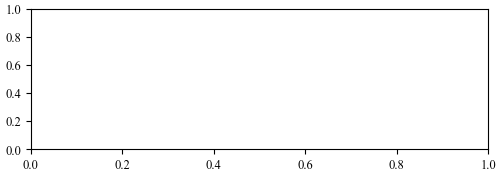

In [54]:
fig, ax = plt.subplots()
print(ZcoupL)

for i, (coup0, coup1) in enumerate(zip(ZcoupL, ZcoupR)):
    ax.scatter(nZ[i], coup0, c='k')
    # ax.scatter(nZ, coup1.T, c='k')